[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Data-Crew/transport-networks-lab/blob/main/Notebooks/accesibilidad/Problemas%20de%20accesibilidad%20II%20-%20Urbanaccess.ipynb)


# Problemas de accesibilidad: el formato GTFS

Del inglés, "General Transit Feed Specification (GTFS)" hace referencia a un formato común para disponibilizar horarios de transporte público e información geográfica asociada como ubicación de paradas o recorridos.

Concretamente, se trata de una colección de (al menos) 6 archivos con información de las agencias de transporte, los recorridos, los viajes y su calendario, los tiempos de llegada y salida y las paradas. Pueden haber campos adicionales, pero estos son los más importantes.


<img src="https://www.researchgate.net/profile/Santi-Phithakkitnukoon/publication/319605381/figure/fig1/AS:551029546074112@1508387089346/Relations-among-different-text-files-of-a-GTFS-feed.pngsvg" width="45%" />

Este formato es verdaderamente útil para análisis de transporte multimodal o para combinar redes de tránsito con redes pedestres.

En este notebook vamos a hacer algo de eso. Vamos a aprovechar la [API](https://apitransporte.buenosaires.gob.ar/console/) de transporte del Gobierno de la Ciudad e Buenos Aires para consultar los schedules de algunos medios de transporte.

Este servicio necesita un `client_id` y un `secret_id`. Ambos se pueden obtener fácilmente registrandose [acá](https://www.buenosaires.gob.ar/desarrollourbano/transporte/apitransporte)

In [1]:
%%capture

# instalamos librerías
!pip install urbanaccess
# Desinstalamos pandas
!pip uninstall pandas -y

# e instalamos una version compatible con urbanaccess
!pip install pandas==1.3.5

In [2]:
import pandas as pd
print(pd.__version__)

1.3.5


In [3]:
# montamos el drive para usar os.
from google.colab import drive
drive.mount('/drive/')

Mounted at /drive/


In [4]:
# importamos urbanaccess y os
import os
import urbanaccess
from urbanaccess.gtfsfeeds import feeds
from urbanaccess import gtfsfeeds
from urbanaccess.gtfs.network import create_transit_net
from urbanaccess.osm.load import ua_network_from_bbox
from urbanaccess.osm.network import create_osm_net
from urbanaccess.network import integrate_network

Primero, creamos una función que nos permita trabajar con las fuentes GTFS de la Ciudad de Buenos Aires.

El Gobierno de la Ciudad cuenta con una [API de transporte](https://apitransporte.buenosaires.gob.ar/) para consultar información sobre distintos medios de transporte.

Para consumir este servicio es necesario que cuentes con un `client_id` y un `secret_id`. Ambos son enviados por mail una vez que te registrás como usuario de la API.

# Redes multimodales

Existen varias formas de construir redes de transporte. Una es a partir de conjuntos de archivos `GTFS`. [Urbanaccess](https://github.com/UDST/urbanaccess) es una librería de python que permite hacer justamente eso.

Básicamente, reconstruye una red de servicios de transporte público a partir de sus horarios y esquemas de circulación.
Tiene la virtud de poder combinar distintas agencias de tránsito en una sola red y, por lo tanto, trabajar con varios modos de transporte.

Además, puede combinar redes pedestres consultadas desde OpenStreetMap.


In [5]:
def download_bsas_gtfsfeeds(vehicles=['default','bus']):
    '''
    Downloads GTFS feeds for subway or bus.
    '''
    for v in vehicles:
        if v == 'default':
            # Por defecto, urbanaccess encuentra el GTFS de subtes
            bsas_subte = gtfsfeeds.search(search_text='BuenosAires',
                                          search_field=None,
                                          match='contains',
                                          add_feed=False)
            url = bsas_subte['dataexchange_url'].values[0]+'latest_zip'
            key = 'BsAs_subte'
            feeds.add_feed(add_dict={key:url}) # agregamos la url
            path = '/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_subte'
            os.mkdir(path)
            gtfsfeeds.download(path) # para descargar su informacion en este directorio
            feeds.remove_feed(del_key=key)

        elif v == 'bus':
            # También podemos especificar otro medio de transporte
            # la URL contiene el client_id y el client secret
            url = 'https://apitransporte.buenosaires.gob.ar/colectivos/feed-gtfs-frequency?client_id=2ec875b51deb463580366bce70b04709&client_secret=b4b3e8717dee4C2C83dA1F744C68Cb78'
            key ='BsAs_colectivos'
            feeds.add_feed(add_dict={key:url})
            path = '/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos'
            os.mkdir(path)
            gtfsfeeds.download(path)
            feeds.remove_feed(del_key=key)
        else:
            raise ValueError("El medio de transporte indicado no ha sido especificado aún")

En una segunda instancia, vamos a necesitar cargar nuestro objeto de tránsito. Para ello, vamos a crear una función que cargue la información que descargamos previamente.

El argumento bbox delimita un área de interés. Para crear un conjunto de coordenadas pueden recurrir a [esta]('https://boundingbox.klokantech.com/) herramienta que les indicará cuáles son las latitudes y longitudes del `bbox`.

In [6]:
def load_transit_object(data_path):
    '''
    Loads transit data object downloaded from GTFS source.
    '''
    validation = True
    verbose = True
    # BsAs bbox
    bbox = (-58.538328,-34.709952,-58.325468,-34.527999)
    remove_stops_outsidebbox = True
    append_definitions = True

    loaded_feeds = urbanaccess.gtfs.load.gtfsfeed_to_df(data_path,
                                                        validation,
                                                        verbose,
                                                        bbox,
                                                        remove_stops_outsidebbox,
                                                        append_definitions)
    return loaded_feeds

Por último, vamos a querer integrar la información que obtuvimos de la fuente GTFS con una red pedestre o de vehículos privados consultada a partir de la API de Open Sreet Map.

In [7]:
def generate_urbanaccess_networks(transit_obj, day_name, timerange_list,
                                 travel_speed_int, osm_network_type):
    '''
    Genera dos tipos de redes viales: GTFS transit + OSM drive|walk network.
    '''
    # Instanciamos nuestra red de transito. Esto crea un objeto global de tipo UrbanAccess
    # ver: https://github.com/UDST/urbanaccess/blob/dev/urbanaccess/gtfs/network.py
    transit_net = create_transit_net(gtfsfeeds_dfs=transit_obj,
                                     day=day_name,
                                     timerange=timerange_list)

    # Creamos nuestra OSM net
    # ver: https://github.com/UDST/urbanaccess/blob/dev/urbanaccess/osm/network.py
    bbox = (-58.538328,-34.709952,-58.325468,-34.527999)
    osm_nodes, osm_edges = ua_network_from_bbox(bbox=bbox)

    # la clase ua_network dentro de la funcion se importa desde 'urbanaccess.network'
    pedestrian_net = create_osm_net(osm_edges=osm_edges,
                                    osm_nodes=osm_nodes,
                                    travel_speed_mph=travel_speed_int,
                                    network_type=osm_network_type)

    return transit_net, pedestrian_net


Con el método `create_transit_net` estamos creando una red o grafo de nodos y ejes para un momento específico de la semana. El objeto que se crea con este método tiene caracter global porque existe por fuera del scope de la función. Es por eso que, puede ser automáticamente llamado por el método `integrate_network`. Esa red que fue creada contiene información sobre las conexiones entre nodos. Un campo bastante universal con el que se trabaja es con el tiempo de viaje de estación a estación. Esto se obtiene desde la fuente GTFS y se utiliza para pesar las conexiones dentro de la red.

In [8]:
# @title Descarga de archivos
es_primera_descarga = True # @param {type:"boolean"}

In [9]:
# Esta función nos va a crear un directorio donde se descargará la información consultada a la API
if es_primera_descarga:
  download_bsas_gtfsfeeds(vehicles=['bus'])
else:
  print("Ya descargaste todos los archivos")

INFO:urbanaccess:Added 1 feeds to gtfs_feeds: {'BsAs_colectivos': 'https://apitransporte.buenosaires.gob.ar/colectivos/feed-gtfs-frequency?client_id=2ec875b51deb463580366bce70b04709&client_secret=b4b3e8717dee4C2C83dA1F744C68Cb78'}


Added 1 feeds to gtfs_feeds: {'BsAs_colectivos': 'https://apitransporte.buenosaires.gob.ar/colectivos/feed-gtfs-frequency?client_id=2ec875b51deb463580366bce70b04709&client_secret=b4b3e8717dee4C2C83dA1F744C68Cb78'}


INFO:urbanaccess:/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_zips does not exist. Directory was created
INFO:urbanaccess:1 GTFS feed(s) will be downloaded here: /drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_zips


/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_zips does not exist. Directory was created
1 GTFS feed(s) will be downloaded here: /drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_zips


INFO:urbanaccess:BsAs_colectivos GTFS feed downloaded successfully. Took 103.59 seconds for 14,153,463.0KB
INFO:urbanaccess:GTFS feed download completed. Took 103.59 seconds
INFO:urbanaccess:/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_text does not exist. Directory was created


BsAs_colectivos GTFS feed downloaded successfully. Took 103.59 seconds for 14,153,463.0KB
GTFS feed download completed. Took 103.59 seconds
/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_text does not exist. Directory was created


INFO:urbanaccess:BsAs_colectivos.zip successfully extracted to: /drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_text/BsAs_colectivos
INFO:urbanaccess:GTFS feed zipfile extraction completed. Took 0.57 seconds for 1 files
INFO:urbanaccess:Removed BsAs_colectivos feed from gtfs_feeds


BsAs_colectivos.zip successfully extracted to: /drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_text/BsAs_colectivos
GTFS feed zipfile extraction completed. Took 0.57 seconds for 1 files
Removed BsAs_colectivos feed from gtfs_feeds


In [10]:
# Define the path to the folder containing the files
data_path = '/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/BsAs_colectivos/gtfsfeed_text/BsAs_colectivos/'

In [11]:
if es_primera_descarga:
  # Listamos todos los archivos y los renombramos para poder leerlos desde urbanaccess
  files = os.listdir(data_path)

  for filename in files:
      if filename.startswith('BUENOS_AIRES\\'):
          new_filename = filename.replace('BUENOS_AIRES\\', '')
          os.rename(os.path.join(data_path, filename), os.path.join(data_path, new_filename))

  print("Archivos despues de renombrar:")
  print(os.listdir(data_path))


Archivos despues de renombrar:
['agency.txt', 'calendar.txt', 'calendar_dates.txt', 'fare_attributes.txt', 'fare_rules.txt', 'feed_info.txt', 'frequencies.txt', 'routes.txt', 'shapes.txt', 'stops.txt', 'stop_times.txt', 'transfers.txt', 'trips.txt']


In [12]:
# Cargamos el feed con la data en formato GTFS
transit_data = load_transit_object(data_path)

INFO:urbanaccess:Checking GTFS text file header whitespace... Reading files using encoding: utf-8 set in configuration.


Checking GTFS text file header whitespace... Reading files using encoding: utf-8 set in configuration.


INFO:urbanaccess:GTFS text file header whitespace check completed. Took 0.24 seconds
INFO:urbanaccess:--------------------------------
INFO:urbanaccess:Processing GTFS feed: 


GTFS text file header whitespace check completed. Took 0.24 seconds
--------------------------------
Processing GTFS feed: 


INFO:urbanaccess:GTFS feed: , calendar_dates uses the same service_id across multiple agency_ids. This feed calendar_dates table will be modified from its original format to provide service_ids for each agency using a one to many join
INFO:urbanaccess:GTFS feed: , calendar uses the same service_id across multiple agency_ids. This feed calendar table will be modified from its original format to provide service_ids for each agency using a one to many join


...

agency.txt agency_name column has more than one agency name listed. Unique agency id was assigned using the agency id and associated agency name.
Unique agency id operation complete. Took 7.18 seconds
Unique GTFS feed id operation complete. Took 0.00 seconds
Records:
           stop_id          unique_agency_id  stop_code             stop_name  \
0      06098005413    transporte_la_union_sa        NaN              18 y 161   
1      06098005414    transporte_la_union_sa        NaN              162 y 19   
2      06098005415    transporte_la_union_sa        NaN              162 y 21   
3      06098005416    transporte_la_union_sa        NaN              162 y 23   
4      06098005417    transporte_la_union_sa        NaN              162 y 25   
...            ...                       ...        ...                   ...   
60799   6805124767  micro_omnibus_tigre_s.a.        NaN  AV. ALVEAR 2300-2398   
60800   6805124768  micro_omnibus_tigre_s.a.        NaN  AV. ALVEAR 2300-2398   
608

INFO:urbanaccess:Appended route type to stops
INFO:urbanaccess:Appended route type to stop_times
INFO:urbanaccess:--------------------------------
INFO:urbanaccess:Added descriptive definitions to stops, routes, stop_times, and trips tables


Appended route type to stops
Appended route type to stop_times
--------------------------------
Added descriptive definitions to stops, routes, stop_times, and trips tables


INFO:urbanaccess:Successfully converted ['departure_time'] to seconds past midnight and appended new columns to stop_times. Took 0.34 seconds
INFO:urbanaccess:1 GTFS feed file(s) successfully read as dataframes:
INFO:urbanaccess:     
INFO:urbanaccess:     Took 9.23 seconds


Successfully converted ['departure_time'] to seconds past midnight and appended new columns to stop_times. Took 0.34 seconds
1 GTFS feed file(s) successfully read as dataframes:
     
     Took 9.23 seconds


In [15]:
transit_data.calendar_dates

,service_id,unique_agency_id,date,exception_type,unique_feed_id
0,DI,union_platense_srl,20240324,2,_1
1,DI,union_platense_srl,20241208,2,_1
2,DI,transporte_larrazabal_c.i.s.a.,20240324,2,_1
3,DI,transporte_larrazabal_c.i.s.a.,20241208,2,_1
4,DI,grupo_linea_179_s.a.,20240324,2,_1
...,...,...,...,...,...
5049,SI,nuevos_rumbos_s.a.t.a.c.i.f.i.,20240817,2,_1
5050,SI,nuevos_rumbos_s.a.t.a.c.i.f.i.,20241012,2,_1
5051,SI,17_de_agosto_s.a.,20240525,2,_1
5052,SI,17_de_agosto_s.a.,20240817,2,_1


/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:1070: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


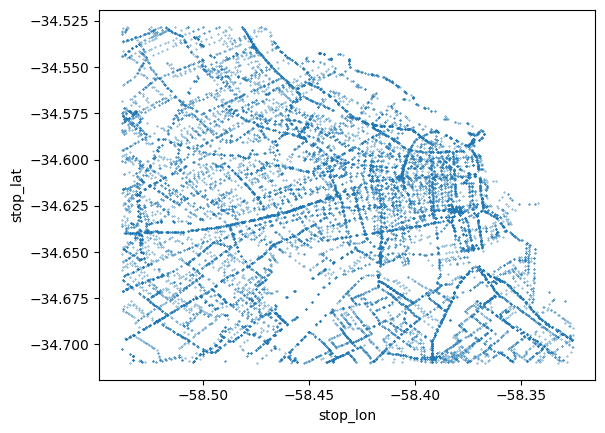

In [16]:
# El objeto transit data contiene información de la red de transito. Por ejemplo, las paradas del servicio
transit_data.stops.plot(kind='scatter', x='stop_lon', y='stop_lat', s=0.1);

Ahora sí, vamos a integrar nuestra red de tránsito con una red pedestre consultada a partir de OSM. Esto nos va a permitir trabajar conjuntamente con los nodos y ejes de las mismas.


In [17]:
%time
transit_net, pedestrian_net = generate_urbanaccess_networks(
    transit_obj=transit_data, day_name='monday',
    timerange_list=['01:00:00', '21:00:00'],
    travel_speed_int=3, osm_network_type='walk'
)

INFO:urbanaccess:Using calendar to extract service_ids to select trips.
INFO:urbanaccess:139 service_ids were extracted from calendar
INFO:urbanaccess:2,082 trip(s) 29.15 percent of 7,142 total trip records were found in calendar for GTFS feed(s): ['']
INFO:urbanaccess:2,082 of 7,142 total trips were extracted representing calendar day: monday. Took 0.04 seconds


CPU times: user 8 µs, sys: 0 ns, total: 8 µs
Wall time: 16 µs
Using calendar to extract service_ids to select trips.
139 service_ids were extracted from calendar
2,082 trip(s) 29.15 percent of 7,142 total trip records were found in calendar for GTFS feed(s): ['']
NOTE: If you expected more trips to have been extracted and your GTFS feed(s) have a calendar_dates file, consider utilizing the calendar_dates_lookup parameter in order to add additional trips based on information inside of calendar_dates. This should only be done if you know the corresponding GTFS feed is using calendar_dates instead of calendar to specify service_ids. When in doubt do not use the calendar_dates_lookup parameter.
2,082 of 7,142 total trips were extracted representing calendar day: monday. Took 0.04 seconds


INFO:urbanaccess:Starting departure stop time interpolation...
INFO:urbanaccess:Departure time records missing from trips following the specified schedule: 40,146 (83.76 percent of 47,929 total records)
INFO:urbanaccess:Interpolating...


Note: Processing may take a long time depending on the number of records. Total unique trips to assess: 1,369
Starting departure stop time interpolation...
Departure time records missing from trips following the specified schedule: 40,146 (83.76 percent of 47,929 total records)
Interpolating...


/usr/local/lib/python3.10/dist-packages/pandas/core/reshape/merge.py:1203: RuntimeWarning: invalid value encountered in cast
  if not (lk == lk.astype(rk.dtype))[~np.isnan(lk)].all():
INFO:urbanaccess:Departure stop time interpolation complete. Took 0.78 seconds


...

Returning OSM data with 148,461 nodes and 47,347 ways...


INFO:osmnet:Edge node pairs completed. Took 72.20 seconds
INFO:osmnet:Returning processed graph with 62,346 nodes and 198,120 edges...
INFO:osmnet:Completed OSM data download and Pandana node and edge table creation in 79.77 seconds
INFO:urbanaccess:checking for low connectivity nodes...


Edge node pairs completed. Took 72.20 seconds
Returning processed graph with 62,346 nodes and 198,120 edges...
Completed OSM data download and Pandana node and edge table creation in 79.77 seconds
checking for low connectivity nodes...


INFO:urbanaccess:246 out of 62,346 nodes (0.39 percent of total) were identified as having low connectivity and have been removed.
INFO:urbanaccess:Completed OSM data download and graph node and edge table creation in 441.57 seconds
INFO:urbanaccess:Created OSM network with travel time impedance using a travel speed of 3 MPH. Took 0.00 seconds


246 out of 62,346 nodes (0.39 percent of total) were identified as having low connectivity and have been removed.
Completed OSM data download and graph node and edge table creation in 441.57 seconds
Created OSM network with travel time impedance using a travel speed of 3 MPH. Took 0.00 seconds


In [18]:
# Integramos ambas redes
# ver integrate en: https://github.com/UDST/urbanaccess/blob/dev/urbanaccess/network.py
try:
  # el headway se define como el intervalo de tiempo entre la llegada de dos vehículos consecutivos (e.g. 5 minutos)
  urbanaccess_net = integrate_network(urbanaccess_network=pedestrian_net,
                                     urbanaccess_gtfsfeeds_df=transit_net,
                                     headways=True,
                                     headway_statistic='mean')
except:
  print(' ')
  print("Omitiendo el calculo de tiempo de espera en una parada de la red de transito")
  urbanaccess_net = integrate_network(urbanaccess_network=pedestrian_net,
                                     urbanaccess_gtfsfeeds_df=None,
                                     headways=False,
                                     headway_statistic=None)
  # investiguemos por que no se pudo calcular el tiempo de espera en el conector de redes
  #dir(transit_data)

INFO:urbanaccess:Loaded UrbanAccess network components comprised of:
INFO:urbanaccess:     Transit: 6,523 nodes and 13,417 edges;
INFO:urbanaccess:     OSM: 62,100 nodes and 197,646 edges
INFO:urbanaccess:Loaded UrbanAccess network components comprised of:
INFO:urbanaccess:     Transit: 6,523 nodes and 13,417 edges;
INFO:urbanaccess:     OSM: 62,100 nodes and 197,646 edges


Loaded UrbanAccess network components comprised of:
     Transit: 6,523 nodes and 13,417 edges;
     OSM: 62,100 nodes and 197,646 edges
 
Omitiendo el calculo de tiempo de espera en una parada de la red de transito
Loaded UrbanAccess network components comprised of:
     Transit: 6,523 nodes and 13,417 edges;
     OSM: 62,100 nodes and 197,646 edges


INFO:urbanaccess:Connector edges between the OSM and transit network nodes successfully completed. Took 2.97 seconds


Connector edges between the OSM and transit network nodes successfully completed. Took 2.97 seconds


INFO:urbanaccess:Edge and node tables formatted for Pandana with integer node ids: id_int, to_int, and from_int. Took 2.71 seconds
INFO:urbanaccess:Network edge and node network integration completed successfully resulting in a total of 68,623 nodes and 224,109 edges:
INFO:urbanaccess:     Transit: 6,523 nodes 13,417 edges;
INFO:urbanaccess:     OSM: 62,100 nodes 197,646 edges; and
INFO:urbanaccess:     OSM/Transit connector: 13,046 edges.


Edge and node tables formatted for Pandana with integer node ids: id_int, to_int, and from_int. Took 2.71 seconds
Network edge and node network integration completed successfully resulting in a total of 68,623 nodes and 224,109 edges:
     Transit: 6,523 nodes 13,417 edges;
     OSM: 62,100 nodes 197,646 edges; and
     OSM/Transit connector: 13,046 edges.


/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:1070: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


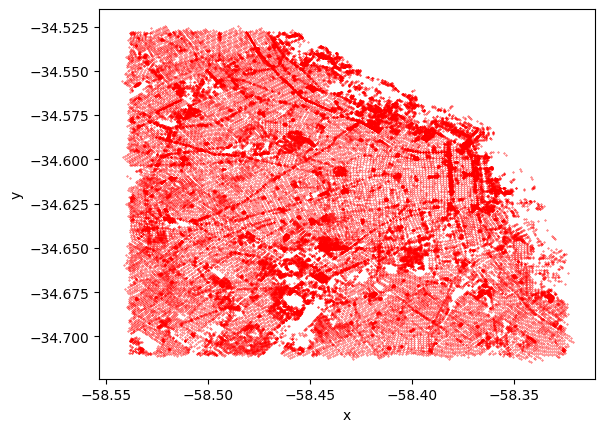

In [19]:
# Estos son los nodos de nuestra red pedestre
urbanaccess_net.osm_nodes.plot(kind='scatter', x='x', y='y', s=0.1, color='red');

In [21]:
dir(urbanaccess_net)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'net_connector_edges',
 'net_edges',
 'net_nodes',
 'osm_edges',
 'osm_nodes',
 'transit_edges',
 'transit_nodes']

In [22]:
urbanaccess_net.net_connector_edges

,from,to,weight,net_type
0,02084000001_linea_sesenta_sa,11692931380,0.100737,transit to osm
1,11692931380,02084000001_linea_sesenta_sa,0.100737,osm to transit
2,06371000046_compaã‘ia_noroeste_s.a.t.,337342658,0.253656,transit to osm
3,337342658,06371000046_compaã‘ia_noroeste_s.a.t.,0.253656,osm to transit
4,06371000047_compaã‘ia_noroeste_s.a.t.,11155272173,0.138109,transit to osm
...,...,...,...,...
13041,4886883021,6840100251_transporte_ideal_san_justo_s.a.,0.325189,osm to transit
13042,6840100262_transporte_ideal_san_justo_s.a.,11052091610,0.128664,transit to osm
13043,11052091610,6840100262_transporte_ideal_san_justo_s.a.,0.128664,osm to transit
13044,6840100263_transporte_ideal_san_justo_s.a.,11052091610,0.137255,transit to osm


La red integrada que creamos con Urbanaccess también puede ser usada para crear un nuevo objeto a partir de `pandana`. Si se fijan bien cómo se hace esto, verán que los argumentos de la clase `pdna.Network` son los nodos/ejes y la impedancia (el tiempo de viaje de los usuarios) de nuestra `urbanaccess_net`.

In [23]:
%%capture
!pip install pandana
import pandana as pdna

In [24]:
%time
transit_ped_net = pdna.Network(urbanaccess_net.net_nodes["x"],
                               urbanaccess_net.net_nodes["y"],
                               urbanaccess_net.net_edges["from_int"],
                               urbanaccess_net.net_edges["to_int"],
                               urbanaccess_net.net_edges[["weight"]],
                               twoway=False)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.34 µs


In [25]:
dir(transit_ped_net)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_imp_name_to_num',
 '_node_indexes',
 '_twoway',
 'aggregate',
 'aggregations',
 'bbox',
 'decays',
 'edges_df',
 'from_hdf5',
 'get_node_ids',
 'impedance_names',
 'init_pois',
 'kdtree',
 'low_connectivity_nodes',
 'nearest_pois',
 'net',
 'node_ids',
 'node_idx',
 'nodes_df',
 'nodes_in_range',
 'plot',
 'poi_category_indexes',
 'poi_category_names',
 'precompute',
 'save_hdf5',
 'set',
 'set_pois',
 'shortest_path',
 'shortest_path_length',
 'shortest_path_lengths',
 'shortest_paths',
 'variable_names']

Algo que se puede hacer con esto, es utilizar la red para estimar medidas de accesibilidad. Por ejemplo, la cantidad de escuelas accesibles en un rango de 15, 30 o 45 minutos a los nodos de nuestra red.

Para eso vamos a contar la cantidad de escuelas por radio censal y le vamos a asignar ese valor al nodo de la red que se encuentre más cerca del centroide del polígono (en nuestro caso, el radio censal).

Si recuerdan, la medida de impedancia que construimos es el tiempo de viaje de nodo a nodo (es decir, un atributo de los ejes). Lo que construimos con esto, es una métrica de **accesibilidad acumulativa**.

Es decir, vamos incorporando cada vez más nodos a medida que ampliamos el umbral de tiempo. Es como si fueramos agregando cada vez más ejes al análisis.

# Accesibilidad a escuelas

Con esto, vamos a combinar `Urbanaccess` con `Pandana` para reconstruir la accesibilidad a escuelas alrededor de la red de transporte de la Ciudad de Buenos Aires.

Para eso, vamos a empezar por contar la cantidad de escuelas para una división administrativa arbitraria. En lo posible la más granular que tengamos. Por ejemplo, radios censales.

In [26]:
import geopandas as gpd

In [27]:
escuelas = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/establecimientos-educativos/establecimientos_educativos_WGS84.geojson')

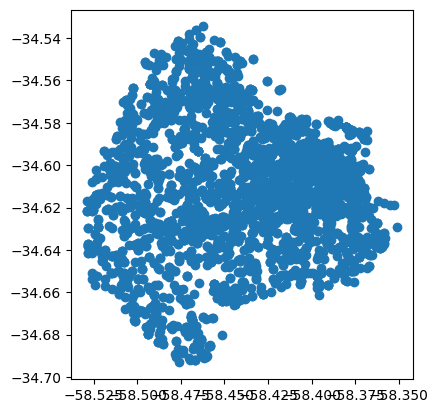

In [28]:
escuelas.plot();

In [29]:
path = '/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/radios_rmba.geojson'
rmba = gpd.read_file(path)

In [30]:
caba = rmba.loc[rmba.link.apply(lambda x: x[:2]=='02')].copy().to_crs(4326)

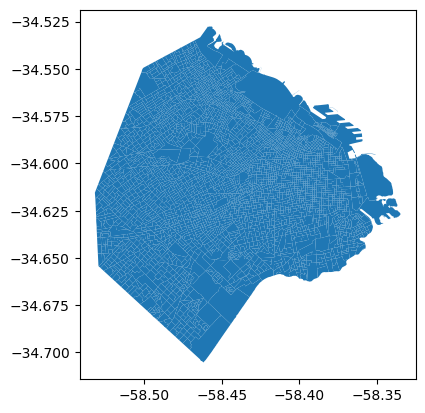

In [31]:
caba.plot();

In [32]:
# asignamos el id del radio a las escuelas
escuela_radio = gpd.sjoin(escuelas, caba[['link','geometry']], predicate='within')
escuela_df = pd.DataFrame(escuela_radio.drop(columns='geometry'))
escuela_df['link'] = escuela_df['link'].astype(str)

In [33]:
# y contamos cuántas hay por radio
cant = escuela_df.groupby('link').size().reset_index(name='count')
cant.set_index('link', inplace=True)

In [34]:
caba['escuelas'] = caba.link.map(cant['count']).fillna(0).astype(int)

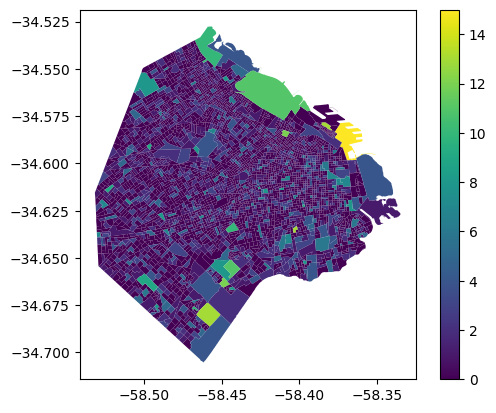

In [35]:
caba.plot(column='escuelas', legend=True, k=3);

In [36]:
import warnings
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS*')

In [37]:
# creamos coordenadas xy a partir del centroide del radio
caba['x'], caba['y'] = caba.geometry.centroid.x, caba.geometry.centroid.y

/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:1070: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


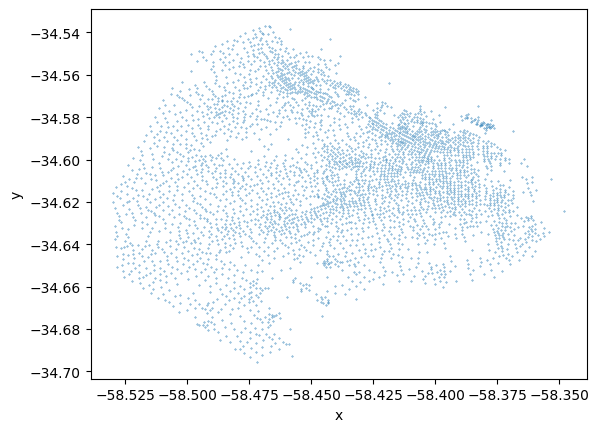

In [38]:
caba.plot(kind='scatter', x='x', y='y', s=0.1);

In [39]:
# Le asignamos el node_id al centroide más cercano para matchear nuestra métrica de accesibilidad
caba['node_id'] = transit_ped_net.get_node_ids(caba['x'], caba['y'])

In [40]:
transit_ped_net.set(caba.node_id, variable = caba.escuelas, name='escuelas')

Ahora sí, creamos nuestra métrica de accesibilidad: La cantidad de escuelas accesibles a 45, 30 y 15 minutos de viaje al nodo más cercano.

In [48]:
%time
print("Calculando accesibilidad")
escuelas_45 = transit_ped_net.aggregate(45, type='sum', decay='linear', name='escuelas')
escuelas_30 = transit_ped_net.aggregate(30, type='sum', decay='linear', name='escuelas')
escuelas_15 = transit_ped_net.aggregate(15, type='sum', decay='linear', name='escuelas')

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.34 µs
Calculando accesibilidad


In [49]:
escuelas_15

,0
id_int,
1,270.476733
2,2.679867
3,2.991467
4,2.327467
5,0.937800
...,...
68619,19.038600
68620,212.356466
68621,0.000000


 Creemos una función para poder plotear estos resultados ...

In [50]:
import matplotlib.pyplot as plt

In [51]:
def plot_accesibility(var):
  fig = plt.subplots(figsize=(15,8))

  cm = plt.cm.get_cmap('gist_heat_r')

  x = transit_ped_net.nodes_df.x
  y = transit_ped_net.nodes_df.y

  net_map = plt.scatter(x, y, c=var, s=4, cmap=cm)#edgecolor='none')

  plt.colorbar(net_map)
  plt.axis("off");

Y efectivamente vemos cómo a medida que aumentamos el tiempo de viaje al nodo más cercano, las intensidades crecen. Es decir, mayor cantidad de escuelas accesibles.

<ipython-input-51-644bc39a116e>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('gist_heat_r')


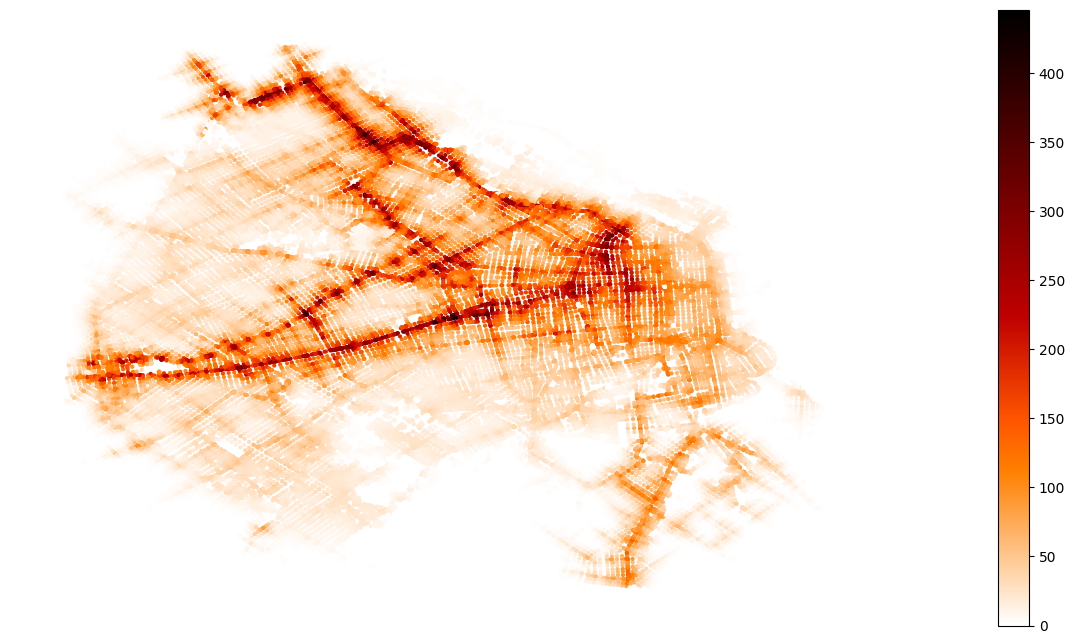

In [52]:
plot_accesibility(var=escuelas_15)

<ipython-input-51-644bc39a116e>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('gist_heat_r')


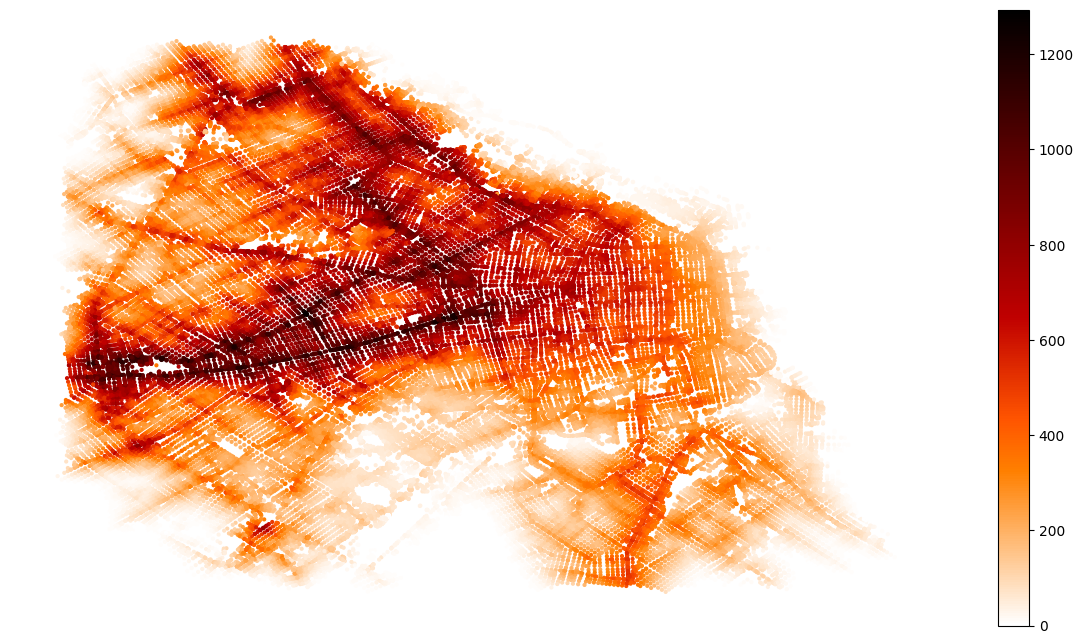

In [53]:
plot_accesibility(var=escuelas_30)

<ipython-input-51-644bc39a116e>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('gist_heat_r')


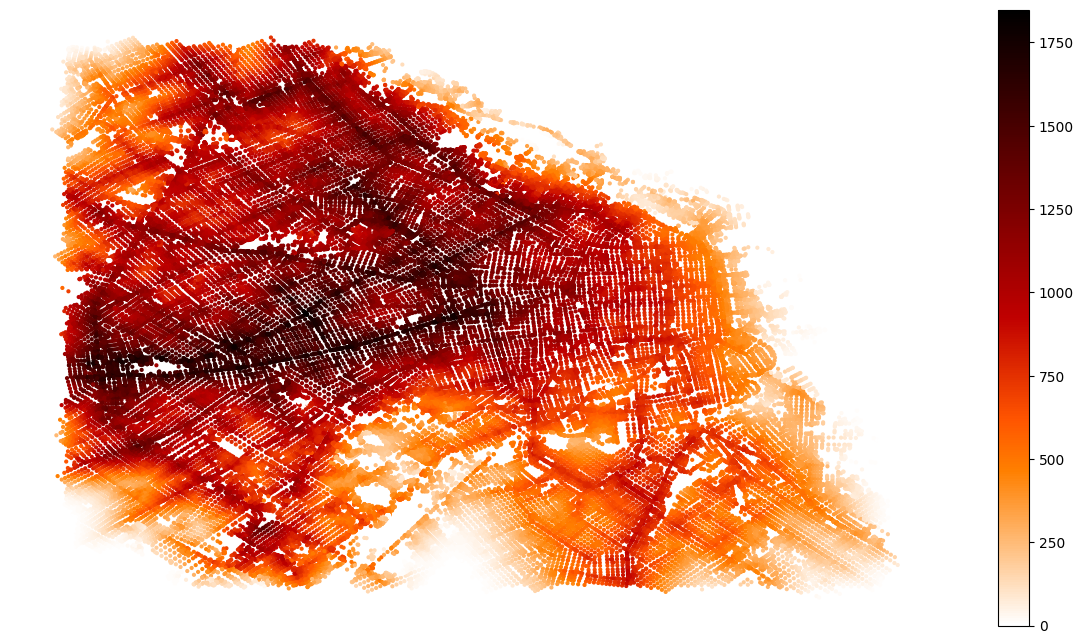

In [54]:
plot_accesibility(var=escuelas_45)

Por último, podemos ver que el output se encuentra un poco distorsionado en sentido horizontal. Esto es así, porque lo estamos ploteando son coordenadas en un plano xy. Pero, en rigor, esta no es aún información espacial en sí misma.
Para eso, deberíamos contar con una geometría con la que no contamos.
Resivemos cómo se ven nuestras métricas de accesibilidad en un plano proyectado con coordenadas específicas.

In [55]:
from shapely.geometry import Point

In [56]:
# creamos una geometría de puntos y le agregamos GKBsAs como sistema de coordenadas de proyección
proj = '+proj=tmerc +lat_0=-34.6297166 +lon_0=-58.4627 +k=0.9999980000000001 +x_0=100000 +y_0=100000 +ellps=intl +units=m +no_defs'
xy_4326 = transit_ped_net.nodes_df.apply(lambda df: Point(df.x,df.y), axis=1).reset_index()
xy_4326.columns = ['id_int', 'geometry']
xy_gkbs = gpd.GeoDataFrame(xy_4326, geometry='geometry', crs=4326).to_crs(proj)
#xy_gkbs.geometry.x

In [57]:
xy_gkbs['accesibility'] = xy_gkbs.index.map(escuelas_15.to_dict())

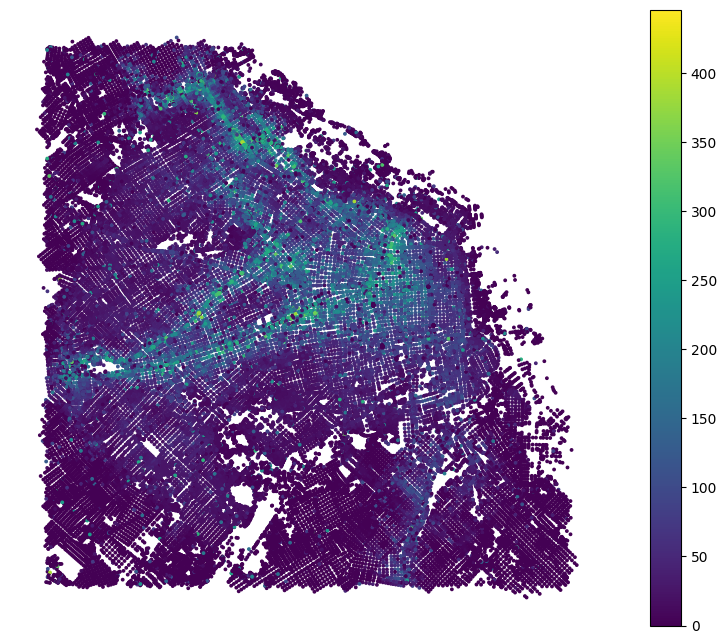

In [58]:
f, ax = plt.subplots(figsize=(12,8))
xy_gkbs.plot(column='accesibility', k=3, markersize=3, legend=True, ax=ax)
ax.set_axis_off();

In [59]:
print(f"Este mapa nos indica a cuantas escuelas de las {len(escuela_df)} disnpobinles en CABA podemos acceder desde cada nodo de la red en un tiempo de viaje determinado")

Este mapa nos indica a cuantas escuelas de las 3044 disnpobinles en CABA podemos acceder desde cada nodo de la red en un tiempo de viaje determinado
